<a href="https://colab.research.google.com/github/Keerthanatamma/nasscom/blob/main/Day_5.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:


# === SETUP: load the provided files (regenerate them if missing) ===
import os
import numpy as np
import pandas as pd

# Each sensor is a linear mix of a few latent machine states + noise, so the 24
# columns are highly correlated -> exactly the structure PCA exploits.
# spec: (name, unit, group, c_load, c_wear, c_thermal, c_vib, base, scale, noise)
SENSORS = [
    ("temp_bearing",   "C",   "thermal",   0.2, 0.6, 0.9, 0.1, 66, 6, 0.30),
    ("temp_motor",     "C",   "thermal",   0.3, 0.4, 0.9, 0.1, 70, 7, 0.30),
    ("temp_gearbox",   "C",   "thermal",   0.2, 0.5, 0.8, 0.2, 62, 6, 0.35),
    ("oil_temp",       "C",   "thermal",   0.2, 0.5, 0.7, 0.1, 58, 5, 0.35),
    ("temp_ambient",   "C",   "thermal",   0.0, 0.0, 0.3, 0.0, 28, 2, 0.60),
    ("vibration_x",    "mm/s","vibration", 0.4, 0.3, 0.1, 0.9, 2.2, 0.6, 0.30),
    ("vibration_y",    "mm/s","vibration", 0.4, 0.3, 0.1, 0.9, 2.0, 0.6, 0.30),
    ("vibration_z",    "mm/s","vibration", 0.3, 0.4, 0.1, 0.8, 1.8, 0.5, 0.35),
    ("acoustic_db",    "dB",  "vibration", 0.3, 0.3, 0.1, 0.7, 78, 5, 0.40),
    ("rpm",            "rpm", "drive",     0.9, 0.1, 0.1, 0.3, 1800, 350, 0.25),
    ("spindle_speed",  "rpm", "drive",     0.9, 0.1, 0.1, 0.3, 6000, 1500, 0.25),
    ("feed_rate",      "mm/min","drive",   0.8, 0.1, 0.1, 0.2, 250, 60, 0.30),
    ("torque",         "Nm",  "drive",     0.8, 0.2, 0.1, 0.3, 120, 25, 0.30),
    ("power_kw",       "kW",  "power",     0.9, 0.2, 0.2, 0.2, 75, 18, 0.25),
    ("current_a",      "A",   "power",     0.8, 0.2, 0.2, 0.2, 22, 5, 0.30),
    ("current_b",      "A",   "power",     0.8, 0.2, 0.2, 0.2, 22, 5, 0.30),
    ("current_c",      "A",   "power",     0.8, 0.2, 0.2, 0.2, 22, 5, 0.30),
    ("load_pct",       "%",   "load",      0.9, 0.1, 0.1, 0.2, 65, 15, 0.25),
    ("pressure_in",    "bar", "hydraulic", 0.5, 0.2, 0.2, 0.2, 80, 12, 0.35),
    ("pressure_out",   "bar", "hydraulic", 0.5, 0.2, 0.2, 0.2, 60, 10, 0.35),
    ("coolant_flow",   "L/min","hydraulic",0.4, 0.2, 0.3, 0.1, 30, 6, 0.40),
    ("oil_level",      "%",   "hydraulic", 0.0,-0.4, 0.0, 0.0, 80, 8, 0.40),
    ("voltage",        "V",   "power",     0.0, 0.0, 0.0, 0.0, 415, 0.3, 1.0),  # near-constant
    ("humidity",       "%",   "ambient",   0.0, 0.0, 0.0, 0.0, 45, 0.2, 1.0),   # near-constant
]


def build_sensors(csv_path="machine_sensors.csv", xlsx_path="sensor_info.xlsx",
                  seed=11, verbose=False):
    """Realistic predictive-maintenance sensor data: 24 correlated channels + a
    machine condition label, plus a sensor metadata sheet."""
    rng = np.random.default_rng(seed)
    N = 2000

    load = rng.normal(0, 1, N)
    wear = rng.normal(0, 1, N)
    thermal = 0.5 * load + 0.8 * rng.normal(0, 1, N)
    vib = 0.4 * load + 0.3 * wear + 0.8 * rng.normal(0, 1, N)

    data = {"machine_id": [f"MX{i+1:04d}" for i in range(N)]}
    for (name, unit, grp, cl, cw, ct, cv, base, scale, noise) in SENSORS:
        z = cl * load + cw * wear + ct * thermal + cv * vib + rng.normal(0, noise, N)
        col = base + scale * z
        col = np.clip(col, 0, None)
        data[name] = col.round(2)
    df = pd.DataFrame(data)

    # machine condition from the latent wear/load/thermal state
    score = 0.6 * wear + 0.4 * load + 0.3 * thermal + rng.normal(0, 0.4, N)
    cond = np.where(score > 1.1, "Failure", np.where(score > 0.2, "Warning", "Normal"))
    df["condition"] = cond

    df.to_csv(csv_path, index=False)
    info = pd.DataFrame([(n, u, g) for (n, u, g, *_rest) in SENSORS],
                        columns=["sensor", "unit", "group"])
    info.to_excel(xlsx_path, index=False)

    if verbose:
        print("sensors:", df.shape, "| metadata:", info.shape)
        print("condition mix:", df["condition"].value_counts(normalize=True).round(3).to_dict())
        num = df.select_dtypes("number")
        print("near-constant (low std) cols:",
              list(num.std().sort_values().head(2).index))
        # how compressible is it?
        from numpy.linalg import svd
        Xs = (num - num.mean()) / num.std()
        s = svd(Xs.fillna(0).values, compute_uv=False)
        ev = (s ** 2) / (s ** 2).sum()
        print("variance in first 5 PCs:", round(ev[:5].sum(), 3))
    return df, info

if not (os.path.exists('machine_sensors.csv') and os.path.exists('sensor_info.xlsx')):
    build_sensors(); print('Generated dataset files.')
else:
    print('Found the provided dataset files.')


import pandas as pd, numpy as np
import matplotlib.pyplot as plt, seaborn as sns
sns.set_theme(style='whitegrid')

df = pd.read_csv('machine_sensors.csv')
info = pd.read_excel('sensor_info.xlsx')
sensors = [c for c in df.columns if c not in ('machine_id', 'condition')]
print('readings:', df.shape, '| sensors:', len(sensors))
df.head(3)



Generated dataset files.
readings: (2000, 26) | sensors: 24


,machine_id,temp_bearing,temp_motor,temp_gearbox,oil_temp,temp_ambient,vibration_x,vibration_y,vibration_z,acoustic_db,...,current_b,current_c,load_pct,pressure_in,pressure_out,coolant_flow,oil_level,voltage,humidity,condition
0,MX0001,61.25,69.26,60.02,56.56,25.46,3.07,3.00,2.59,80.22,...,23.12,23.46,66.89,84.58,61.36,27.83,83.31,415.31,45.07,Normal
1,MX0002,72.66,78.22,68.98,62.77,29.08,2.43,2.26,2.21,78.41,...,30.54,25.88,84.32,90.57,71.68,35.50,77.44,414.68,45.11,Warning
2,MX0003,65.03,74.08,61.96,57.83,28.65,2.22,1.69,1.99,81.35,...,28.56,26.87,82.34,89.42,64.28,35.80,77.43,415.48,45.13,Warning


In [ ]:
print('sensors:',len(sensors))
print('readings:', len(df))

corr_matrix = df[sensors].corr().abs()

corr_pairs = corr_matrix.unstack()

corr_pairs = corr_pairs[corr_pairs < 1]

print(corr_pairs.sort_values(ascending=False).head())

sensors: 24
readings: 2000
spindle_speed  rpm              0.951095
rpm            spindle_speed    0.951095
               load_pct         0.949709
load_pct       rpm              0.949709
               spindle_speed    0.946665
dtype: float64


In [ ]:

reduced = df[sensors].drop(columns=near_constant)
corr_matrix = reduced.corr().abs()
upper_tri = corr_matrix.where(np.triu(np.ones(corr_matrix.shape), k=1).astype(bool))
print(upper_tri.stack().sort_values(ascending=False).head())
to_drop = [column for column in upper_tri.columns if any(upper_tri[column] > 0.9)]

print("Highly correlated columns to drop:")
print(to_drop)

rpm            spindle_speed    0.951095
               load_pct         0.949709
spindle_speed  load_pct         0.946665
               power_kw         0.945930
vibration_x    vibration_y      0.944855
dtype: float64
Highly correlated columns to drop:
['temp_motor', 'temp_gearbox', 'oil_temp', 'vibration_y', 'vibration_z', 'acoustic_db', 'spindle_speed', 'feed_rate', 'torque', 'power_kw', 'current_a', 'current_b', 'current_c', 'load_pct']


<Axes: >

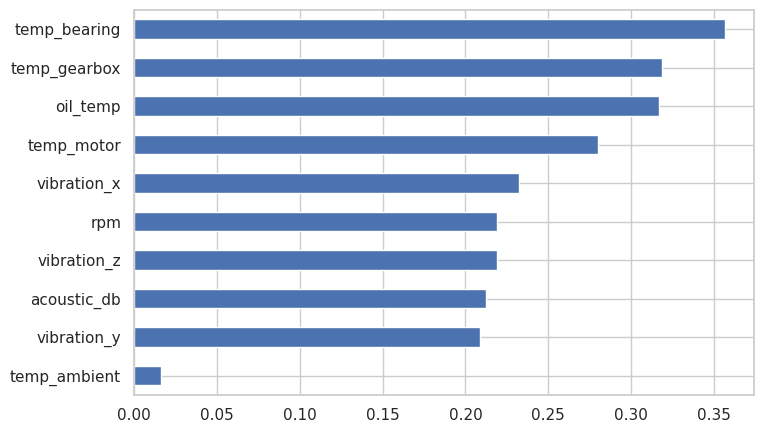

In [ ]:
from sklearn.feature_selection import mutual_info_classif
mi= mutual_info_classif(df[sensors], df['condition'])
top10_mi=pd.Series(mi, index=sensors).head(10)
plt.figure(figsize=(8,5))
top10_mi.sort_values().plot(kind='barh')

In [ ]:
# -----------------------------------------------------------
# 🔹 4A. STANDARDISE (essential!) THEN FIT PCA
# -----------------------------------------------------------
from sklearn.preprocessing import StandardScaler
from sklearn.decomposition import PCA

X = df[sensors].values
Xs = StandardScaler().fit_transform(X)      # PCA needs standardised inputs
pca = PCA().fit(Xs)
evr = pca.explained_variance_ratio_
print('Variance explained by the first 5 components:')
print((evr[:5] * 100).round(1))
print('First 5 components together:', round(evr[:5].sum() * 100, 1), '%')

Variance explained by the first 5 components:
[67.8  6.4  5.4  4.2  4.1]
First 5 components together: 87.9 %


In [ ]:
cum = np.cumsum(evr)
components_90 = np.argmax(cum >= 0.90) + 1
print("Components needed for 90% variance:", components_90)
print("Compression:", len(sensors), "->", components_90)

Components needed for 90% variance: 6
Compression: 24 -> 6


In [ ]:
top3= pd.Series(pca.components_[0], index=sensors).abs().sort_values().tail(3)
print(top3)

current_a    0.234046
current_c    0.234338
power_kw     0.236235
dtype: float64


In [ ]:
from sklearn.pipeline import make_pipeline
from sklearn.linear_model import LogisticRegression
from sklearn.model_selection import cross_val_score

y = df['condition'] # Define the target variable

components = [2, 4, 6, 8, 10]
for n in components:
    model = make_pipeline(
        StandardScaler(),
        PCA(n_components=n),
        LogisticRegression(max_iter=1000)
    )

    score = cross_val_score(model, X, y, cv=5).mean()

    print(f"{n} components -> Accuracy: {score:.3f}")

2 components -> Accuracy: 0.747
4 components -> Accuracy: 0.742
6 components -> Accuracy: 0.754
8 components -> Accuracy: 0.748
10 components -> Accuracy: 0.745


In [ ]:


# === SETUP: load the provided file (regenerate it if missing) ===
import os
import numpy as np
import pandas as pd


def build_loans(csv_path="loan_applications.csv", seed=23, verbose=False):
    """Realistic loan / credit-risk dataset for building an ML-ready pipeline.

    Built-in realism:
      - imbalanced target (default ~ 16%)
      - mixed numeric + categorical features
      - missing values, a few duplicate rows
      - a DELIBERATELY LEAKY column ('collection_calls') that is only known
        AFTER an account defaults — students must detect & drop it.
    """
    rng = np.random.default_rng(seed)
    N = 4000

    age = np.clip(rng.normal(40, 12, N), 21, 75).round().astype(int)
    income = np.clip(rng.lognormal(11.0, 0.45, N), 12000, None).round(-2)         # right-skewed
    employment_years = np.clip(rng.gamma(3, 2.2, N), 0, 40).round(1)
    credit_score = np.clip(rng.normal(680, 70, N), 300, 850).round().astype(int)
    loan_amount = np.clip(rng.lognormal(10.2, 0.5, N), 1000, None).round(-2)
    loan_term = rng.choice([12, 24, 36, 48, 60], N, p=[.12, .23, .33, .17, .15])
    num_existing_loans = rng.poisson(1.1, N)
    dti = np.clip(rng.normal(25, 10, N) + (loan_amount / (income + 1)) * 15, 2, 90).round(1)
    interest_rate = np.clip(14 - (credit_score - 680) / 35 + rng.normal(0, 1.2, N), 4, 28).round(2)
    home = rng.choice(["Rent", "Own", "Mortgage"], N, p=[.45, .20, .35])
    purpose = rng.choice(["Car", "Home", "Education", "Business", "Personal"],
                         N, p=[.22, .18, .15, .15, .30])
    region = rng.choice(["North", "South", "East", "West", "Central"],
                        N, p=[.24, .22, .18, .20, .16])
    prior_default = rng.choice(["Yes", "No"], N, p=[.14, .86])

    # ---- default risk (real signal) ----
    z = (-2.0
         - 0.012 * (credit_score - 680)
         + 0.035 * (dti - 28)
         + 0.06 * (interest_rate - 12)
         - 0.0000035 * (income - 60000)
         + 0.9 * (prior_default == "Yes")
         + 0.12 * num_existing_loans)
    p = 1 / (1 + np.exp(-z))
    default = (rng.random(N) < p).astype(int)

    # ---- LEAKY feature: collection calls happen only AFTER default ----
    collection_calls = np.where(default == 1, rng.poisson(6, N), rng.poisson(0.2, N))

    df = pd.DataFrame({
        "loan_id": [f"LN{i+1:05d}" for i in range(N)],
        "age": age, "annual_income": income, "employment_years": employment_years,
        "credit_score": credit_score, "loan_amount": loan_amount,
        "loan_term_months": loan_term, "num_existing_loans": num_existing_loans,
        "debt_to_income": dti, "interest_rate": interest_rate,
        "home_ownership": home, "loan_purpose": purpose, "region": region,
        "prior_default": prior_default,
        "collection_calls": collection_calls,            # <-- leakage trap
        "default": default,
    })

    # ---- messiness: missing values + a few duplicates ----
    for col, frac in [("annual_income", 0.05), ("employment_years", 0.06), ("home_ownership", 0.02)]:
        idx = rng.choice(N, int(frac * N), replace=False)
        df.loc[idx, col] = np.nan
    df = pd.concat([df, df.sample(12, random_state=2)], ignore_index=True)

    df.to_csv(csv_path, index=False)
    if verbose:
        print("loans:", df.shape)
        print("default rate:", round(df["default"].mean(), 3))
        corr = df[["collection_calls", "credit_score", "debt_to_income", "default"]].corr()["default"]
        print("corr with default:\n", corr.round(3).to_string())
        print("duplicates:", int(df.duplicated().sum()),
              "| missing income:", int(df["annual_income"].isna().sum()))
    return df

if not os.path.exists('loan_applications.csv'):
    build_loans(); print('Generated dataset file.')
else:
    print('Found the provided dataset file.')


import pandas as pd, numpy as np
df = pd.read_csv('loan_applications.csv')
print('shape:', df.shape)
print('default rate:', round(df['default'].mean(), 3))
df.head(3)


Generated dataset file.
shape: (4012, 16)
default rate: 0.239


,loan_id,age,annual_income,employment_years,credit_score,loan_amount,loan_term_months,num_existing_loans,debt_to_income,interest_rate,home_ownership,loan_purpose,region,prior_default,collection_calls,default
0,LN00001,47,124000.0,8.3,757,18600.0,36,1,19.4,12.33,Own,Car,Central,No,1,0
1,LN00002,43,97200.0,5.0,677,26500.0,12,0,18.9,15.87,Own,Business,East,Yes,0,0
2,LN00003,39,119100.0,5.1,591,16900.0,48,2,37.3,18.65,Rent,Personal,West,No,0,0


In [ ]:


# -----------------------------------------------------------
# 🔹 1A. DROP DUPLICATES; NOTE MISSINGNESS (the pipeline will impute)
# -----------------------------------------------------------
print('duplicate rows:', df.duplicated().sum())
df = df.drop_duplicates().reset_index(drop=True)
print('after drop:', df.shape)
print('\nmissing values:')
print(df.isna().sum()[lambda s: s > 0])



duplicate rows: 12
after drop: (4000, 16)

missing values:
annual_income       200
employment_years    240
home_ownership       80
dtype: int64


In [ ]:
# -----------------------------------------------------------
# 🔹 2A. y = what we predict; X = what we're allowed to use
# -----------------------------------------------------------
y = df['default']
X = df.drop(columns=['default', 'loan_id'])   # drop the target and the ID
print('X:', X.shape, '| y:', y.shape)
print('feature columns:', list(X.columns))


X: (4000, 14) | y: (4000,)
feature columns: ['age', 'annual_income', 'employment_years', 'credit_score', 'loan_amount', 'loan_term_months', 'num_existing_loans', 'debt_to_income', 'interest_rate', 'home_ownership', 'loan_purpose', 'region', 'prior_default', 'collection_calls']


In [ ]:
from sklearn.pipeline import make_pipeline
from sklearn.impute import SimpleImputer
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LogisticRegression
from sklearn.model_selection import cross_val_score

pipe_q = make_pipeline(SimpleImputer(strategy='median'), StandardScaler(),
                       LogisticRegression(max_iter=1000, random_state=42))

# 1-2. CV accuracy WITH the leaky column
X_leaky = df.drop(columns=['default','loan_id']).select_dtypes('number') # (which still contains collection_calls)
score_leaky = cross_val_score(pipe_q, X_leaky, y, cv=5).mean()

# 3. CV accuracy WITHOUT it
X_no_leakage = X_leaky.drop(columns=['collection_calls'])
score_no_leakage = cross_val_score(pipe_q, X_no_leakage, y, cv=5).mean()

# 4. Report both and explain the gap:
print(f"CV accuracy WITH 'collection_calls': {score_leaky:.3f}")
print(f"CV accuracy WITHOUT 'collection_calls': {score_no_leakage:.3f}")
print("\nExplanation: The 'collection_calls' feature is a classic example of data leakage.")
print("It contains information that would only be available *after* a loan defaults.")
print("Including it in the model leads to an artificially high and misleading accuracy, ")
print("as the model essentially 'sees the future'. When removed, the accuracy drops ")
print("to a more realistic level, highlighting the importance of careful feature selection.")

CV accuracy WITH 'collection_calls': 0.988
CV accuracy WITHOUT 'collection_calls': 0.773

Explanation: The 'collection_calls' feature is a classic example of data leakage.
It contains information that would only be available *after* a loan defaults.
Including it in the model leads to an artificially high and misleading accuracy, 
as the model essentially 'sees the future'. When removed, the accuracy drops 
to a more realistic level, highlighting the importance of careful feature selection.


In [ ]:
from sklearn.model_selection import train_test_split

# 1. non-stratified split + its default rates
X_train, X_test, y_train, y_test = train_test_split(X, y,test_size=0.2,random_state=42)

print("Train Default Rate :", y_train.mean())
print("Test Default Rate  :", y_test.mean())

Train Default Rate : 0.241875
Test Default Rate  : 0.22875


In [ ]:


# === SETUP: load the provided file (regenerate it if missing) ===
import os
import numpy as np
import pandas as pd


def build_energy(csv_path="energy_consumption.csv", seed=5, verbose=False):
    """Clean regression dataset for coding gradient descent from scratch:
    predict a building's daily energy use (kWh).

    - 'floor_area_sqft' has a strong, mostly-linear relationship with energy
      (ideal for the single-feature loss-bowl demo).
    - 'occupancy' is on a very different scale from floor_area, so the two
      together make the feature-scaling-speeds-optimization demo land clearly.
    """
    rng = np.random.default_rng(seed)
    N = 600

    floor_area = np.clip(rng.normal(2200, 900, N), 300, 6000).round(0)   # ~100s-1000s
    occupancy = np.clip(rng.normal(25, 12, N), 1, 80).round(0)           # ~tens
    avg_temp_c = np.clip(rng.normal(24, 6, N), 8, 42).round(1)
    insulation = rng.integers(1, 6, N)                                   # 1 (poor) .. 5 (great)

    # daily energy (kWh): dominated by floor area, plus occupancy & cooling load
    energy = (1.05 * floor_area
              + 18.0 * occupancy
              + 35.0 * np.clip(avg_temp_c - 22, 0, None)   # cooling above 22C
              - 60.0 * insulation
              + rng.normal(0, 120, N))
    energy = np.clip(energy, 50, None).round(1)

    df = pd.DataFrame({
        "building_id": [f"BLD{i+1:04d}" for i in range(N)],
        "floor_area_sqft": floor_area.astype(int),
        "occupancy": occupancy.astype(int),
        "avg_temp_c": avg_temp_c,
        "insulation_score": insulation,
        "energy_kwh": energy,
    })
    df.to_csv(csv_path, index=False)
    if verbose:
        print("energy:", df.shape)
        print("corr(area, energy):", round(df["floor_area_sqft"].corr(df["energy_kwh"]), 3))
        print("energy range:", df["energy_kwh"].min(), "-", df["energy_kwh"].max())
    return df

if not os.path.exists('energy_consumption.csv'):
    build_energy(); print('Generated dataset file.')
else:
    print('Found the provided dataset file.')


import pandas as pd, numpy as np
import matplotlib.pyplot as plt
df = pd.read_csv('energy_consumption.csv')
print('shape:', df.shape)
df.head(3)



Generated dataset file.
shape: (600, 6)


,building_id,floor_area_sqft,occupancy,avg_temp_c,insulation_score,energy_kwh
0,BLD0001,1478,49,28.0,4,2206.6
1,BLD0002,1008,16,8.0,1,1258.1
2,BLD0003,1976,27,21.4,1,2221.9


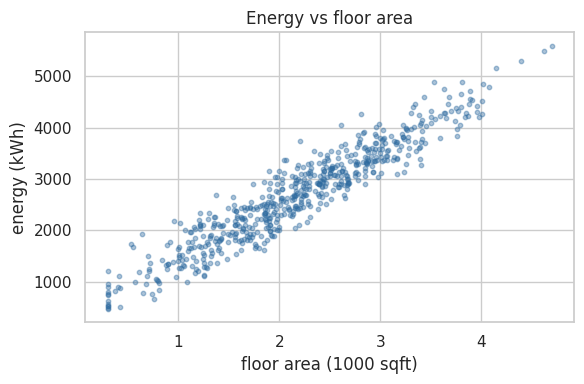

MSE at w=0, b=0: 8176582.4


In [ ]:
# -----------------------------------------------------------
# 🔹 1A. ONE FEATURE: floor_area -> energy_kwh
# -----------------------------------------------------------
# Work in thousands of sqft so the numbers are friendly.
x = df['floor_area_sqft'].values / 1000.0      # feature
y = df['energy_kwh'].values                    # target

fig, ax = plt.subplots(figsize=(6, 4))
ax.scatter(x, y, s=10, alpha=0.4, color='#2D6A9F')
ax.set_xlabel('floor area (1000 sqft)'); ax.set_ylabel('energy (kWh)')
ax.set_title('Energy vs floor area'); plt.tight_layout(); plt.show()

def mse(w, b):
    pred = w * x + b
    return np.mean((y - pred) ** 2)
print('MSE at w=0, b=0:', round(mse(0, 0), 1))

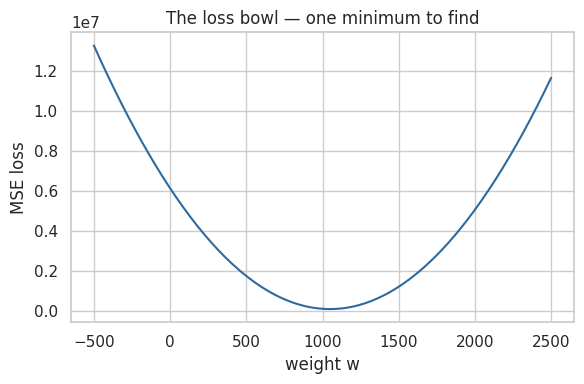

The curve is convex: a single lowest point gradient descent can reach.


In [ ]:


# -----------------------------------------------------------
# 🔹 2A. SWEEP THE WEIGHT w (fix b) AND PLOT THE LOSS
# -----------------------------------------------------------
b_fixed = y.mean() - 1.05 * x.mean() * 1000   # a reasonable intercept
ws = np.linspace(-500, 2500, 200)
losses = [mse(w, b_fixed) for w in ws]
fig, ax = plt.subplots(figsize=(6, 4))
ax.plot(ws, losses, color='#2D6A9F')
ax.set_xlabel('weight w'); ax.set_ylabel('MSE loss')
ax.set_title('The loss bowl — one minimum to find')
plt.tight_layout(); plt.show()
print('The curve is convex: a single lowest point gradient descent can reach.')



learned: w=1042.9, b=426.2
loss: 699089 (start) -> 94737 (end)


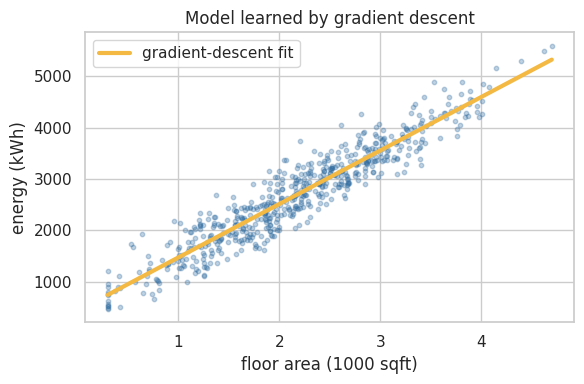

In [ ]:


# -----------------------------------------------------------
# 🔹 3A. THE GRADIENTS OF MSE, THEN THE UPDATE LOOP
# -----------------------------------------------------------
# MSE = mean((y - (w*x+b))^2)
#   dL/dw = -2 * mean(x * (y - pred))
#   dL/db = -2 * mean(    (y - pred))
def gradients(w, b):
    pred = w * x + b
    err = y - pred
    dw = -2 * np.mean(x * err)
    db = -2 * np.mean(err)
    return dw, db

def gradient_descent(lr=0.1, epochs=100):
    w, b = 0.0, 0.0
    history = []
    for _ in range(epochs):
        dw, db = gradients(w, b)
        w -= lr * dw          # the update rule:  theta <- theta - lr * grad
        b -= lr * db
        history.append(mse(w, b))
    return w, b, history

w, b, hist = gradient_descent(lr=0.1, epochs=100)
print(f'learned: w={w:.1f}, b={b:.1f}')
print(f'loss: {hist[0]:.0f} (start) -> {hist[-1]:.0f} (end)')


# Plot the fitted line over the data
fig, ax = plt.subplots(figsize=(6, 4))
ax.scatter(x, y, s=10, alpha=0.3, color='#2D6A9F')
xs = np.linspace(x.min(), x.max(), 50)
ax.plot(xs, w * xs + b, color='#F4B942', lw=3, label='gradient-descent fit')
ax.set_xlabel('floor area (1000 sqft)'); ax.set_ylabel('energy (kWh)')
ax.legend(); ax.set_title('Model learned by gradient descent')
plt.tight_layout(); plt.show()



In [ ]:
# MSE = mean((y - (w*x+b))^2)
#   dL/dw = -2 * mean(x * (y - pred))
#   dL/db = -2 * mean(    (y - pred))
def gradients(w, b):
    pred = w * x + b
    err = y - pred
    dw = -2 * np.mean(x * err)
    db = -2 * np.mean(err)
    return dw, db

# 1. gradients at the start
dw, db = gradients(0, 0)

print("dw =", dw)
print("db =", db)


# 2. one manual update step (lr=0.1)
lr = 0.1

w_new = 0 - lr * dw
b_new = 0 - lr * db

print("New w =", w_new)
print("New b =", b_new)


# 3. show the loss dropped
initial_loss = mse(0, 0)
new_loss = mse(w_new, b_new)

print("Initial Loss =", initial_loss)
print("Loss After One Step =", new_loss)

print("Loss decreased?", new_loss < initial_loss)

dw = -13293.906055333331
db = -5395.344
New w = 1329.3906055333332
New b = 539.5344
Initial Loss = 8176582.3501
Loss After One Step = 699089.0822761774
Loss decreased? True


In [ ]:
# 1. run with an overly large lr
w_big, b_big, h_big = gradient_descent(lr=1.5, epochs=30)

# 2. print the final loss (expect explosion)
print("Final Loss:", h_big[-1])

# Optional: see all losses
print(h_big)

Final Loss: 2.349099452373262e+82
[np.float64(2648331773.9033885), np.float64(867767271221.7633), np.float64(284347610277013.6), np.float64(9.317425872683608e+16), np.float64(3.053109004050589e+19), np.float64(1.0004345318112441e+22), np.float64(3.2781969170197444e+24), np.float64(1.074190732631104e+27), np.float64(3.519879248497255e+29), np.float64(1.1533845477939338e+32), np.float64(3.779379408136691e+34), np.float64(1.238416860878528e+37), np.float64(4.0580110004471897e+39), np.float64(1.3297181102709183e+42), np.float64(4.3571844743338896e+44), np.float64(1.4277504680678714e+47), np.float64(4.678414262870196e+49), np.float64(1.533010179618223e+52), np.float64(5.023326449443797e+54), np.float64(1.6460300755449507e+57), np.float64(5.393666999082876e+59), np.float64(1.7673822689639684e+62), np.float64(5.79131059663001e+64), np.float64(1.8976810515531324e+67), np.float64(6.2182701365030466e+69), np.float64(2.0375860031315177e+72), np.float64(6.676706912080672e+74), np.float64(2.1878053

In [ ]:
import numpy as np
from sklearn.preprocessing import StandardScaler

# The error 'NameError: name 'h_raw' is not defined' occurs because the variables
# h_raw and h_scaled, which are expected to hold the history of losses from
# gradient descent, have not been defined in previous cells or in the current scope.

# We already have 'hist' from a previous gradient_descent run on unscaled data, so we can use it for h_raw.
h_raw = hist

# To get h_scaled, we need to scale the features and rerun gradient descent.
# We must temporarily modify the global x and y because the mse and gradients functions
# implicitly use these global variables.

# Save original x and y globals
original_x_global = globals()['x']
original_y_global = globals()['y']

# Scale features
scaler_x = StandardScaler()
x_scaled = scaler_x.fit_transform(original_x_global.reshape(-1, 1)).flatten()
scaler_y = StandardScaler()
y_scaled = scaler_y.fit_transform(original_y_global.reshape(-1, 1)).flatten()

# Temporarily set global x and y to scaled versions
globals()['x'] = x_scaled
globals()['y'] = y_scaled

# Run gradient descent on scaled data
w_scaled, b_scaled, h_scaled = gradient_descent(lr=0.1, epochs=100)

# Restore original x and y globals
globals()['x'] = original_x_global
globals()['y'] = original_y_global

# 1. final losses
print("Final loss (Unscaled Features):", h_raw[-1])
print("Final loss (Scaled Features):", h_scaled[-1])

Final loss (Unscaled Features): 94736.73751380914
Final loss (Scaled Features): 0.10536275872590611


In [ ]:
from sklearn.linear_model import LinearRegression

x_new = 3

# Create and fit the sklearn LinearRegression model if it doesn't exist or is not fitted
# This ensures lr_model is defined before being used.
lr_model = LinearRegression()
lr_model.fit(x.reshape(-1, 1), y)

# sklearn prediction
sklearn_pred = lr_model.predict([[x_new]])[0]

# gradient descent prediction
gd_pred = w * x_new + b

print("Sklearn Prediction       :", sklearn_pred)
print("Gradient Descent Prediction:", gd_pred)
print("Difference               :", abs(sklearn_pred - gd_pred))

Sklearn Prediction       : 3554.835804148579
Gradient Descent Prediction: 3554.894838088366
Difference               : 0.05903393978724125
